## Naive bayes - aprendizagem bayesiana


- Caso A, B e C, risco de crédito (exemplo). Previsão do risco de fazer empréstimo, se vai ter risco baixo, moderado e alto. 


Naive bayes com scikit-learn - base risco de crédito

Naive bayes com scikit-learn - base crédito

Naive bayes com scikit-learn -base censo


- Entender Naive Bayes => Abordagem probabilística (Teorema de Bayes)

Exemplo de aplicação:

servidor do e-mail classifica como spam

mineração de emoções

separação de documentos (texto)

risco de crédito

- aprendizagem

contagem probabilistica

- Naive Bayes – Correção laplaciana.

- Tarefas de classificação de texto

# 3.8) Naïve Bayes

## Base risco de crédito

In [70]:
import pandas as pd
# base do critério dos riscos
base_risco_credito = pd.read_csv('risco_credito.csv')
base_risco_credito

,historia,divida,garantias,renda,risco
0,ruim,alta,nenhuma,0_15,alto
1,desconhecida,alta,nenhuma,15_35,alto
2,desconhecida,baixa,nenhuma,15_35,moderado
3,desconhecida,baixa,nenhuma,acima_35,alto
4,desconhecida,baixa,nenhuma,acima_35,baixo
5,desconhecida,baixa,adequada,acima_35,baixo
6,ruim,baixa,nenhuma,0_15,alto
7,ruim,baixa,adequada,acima_35,moderado
8,boa,baixa,nenhuma,acima_35,baixo
9,boa,alta,adequada,acima_35,baixo


In [71]:
base_risco_credito.columns

Index(['historia', 'divida', 'garantias', 'renda', 'risco'], dtype='object')

Vamos coletar os atributos ['historia', 'divida', 'garantias', 'renda'] ,pois queremos achar o risco



In [72]:
X_risco_credito = base_risco_credito.iloc[:, 0:4].values
X_risco_credito

array([['ruim', 'alta', 'nenhuma', '0_15'],
       ['desconhecida', 'alta', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'adequada', 'acima_35'],
       ['ruim', 'baixa', 'nenhuma', '0_15'],
       ['ruim', 'baixa', 'adequada', 'acima_35'],
       ['boa', 'baixa', 'nenhuma', 'acima_35'],
       ['boa', 'alta', 'adequada', 'acima_35'],
       ['boa', 'alta', 'nenhuma', '0_15'],
       ['boa', 'alta', 'nenhuma', '15_35'],
       ['boa', 'alta', 'nenhuma', 'acima_35'],
       ['ruim', 'alta', 'nenhuma', '15_35']], dtype=object)

In [73]:
y_risco_credito = base_risco_credito.iloc[:, 4].values  #só a coluna de risco
y_risco_credito

array(['alto', 'alto', 'moderado', 'alto', 'baixo', 'baixo', 'alto',
       'moderado', 'baixo', 'baixo', 'alto', 'moderado', 'baixo', 'alto'],
      dtype=object)

# Transformar em algoritmos numéricos 

In [74]:
from sklearn.preprocessing import LabelEncoder
label_encoder_historia = LabelEncoder()
label_encoder_divida = LabelEncoder()
label_encoder_garantia = LabelEncoder()
label_encoder_renda = LabelEncoder()

In [75]:
# adicionar os indices
X_risco_credito

array([['ruim', 'alta', 'nenhuma', '0_15'],
       ['desconhecida', 'alta', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', '15_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'nenhuma', 'acima_35'],
       ['desconhecida', 'baixa', 'adequada', 'acima_35'],
       ['ruim', 'baixa', 'nenhuma', '0_15'],
       ['ruim', 'baixa', 'adequada', 'acima_35'],
       ['boa', 'baixa', 'nenhuma', 'acima_35'],
       ['boa', 'alta', 'adequada', 'acima_35'],
       ['boa', 'alta', 'nenhuma', '0_15'],
       ['boa', 'alta', 'nenhuma', '15_35'],
       ['boa', 'alta', 'nenhuma', 'acima_35'],
       ['ruim', 'alta', 'nenhuma', '15_35']], dtype=object)

In [76]:
X_risco_credito[:,0] = label_encoder_historia.fit_transform(X_risco_credito[:,0])
X_risco_credito[:,1] = label_encoder_divida.fit_transform(X_risco_credito[:,1])
X_risco_credito[:,2] = label_encoder_garantia.fit_transform(X_risco_credito[:,2])
X_risco_credito[:,3] = label_encoder_renda.fit_transform(X_risco_credito[:,3])

In [77]:
X_risco_credito

array([[2, 0, 1, 0],
       [1, 0, 1, 1],
       [1, 1, 1, 1],
       [1, 1, 1, 2],
       [1, 1, 1, 2],
       [1, 1, 0, 2],
       [2, 1, 1, 0],
       [2, 1, 0, 2],
       [0, 1, 1, 2],
       [0, 0, 0, 2],
       [0, 0, 1, 0],
       [0, 0, 1, 1],
       [0, 0, 1, 2],
       [2, 0, 1, 1]], dtype=object)

labelencoder mais fácil para os testes

In [78]:
# salvar o arquivo
import pickle
with open('risco_credito.pkl', 'wb') as f:
  pickle.dump([X_risco_credito, y_risco_credito], f)

In [79]:
y_risco_credito

array(['alto', 'alto', 'moderado', 'alto', 'baixo', 'baixo', 'alto',
       'moderado', 'baixo', 'baixo', 'alto', 'moderado', 'baixo', 'alto'],
      dtype=object)

In [80]:
from sklearn.naive_bayes import GaussianNB
# primeiro experimento: receberá o objeto das classes gaussianNB

# distribuição estatística, distribuição normal
# vamos treinar o algoritmo
naive_risco_credito = GaussianNB()
naive_risco_credito.fit(X_risco_credito, y_risco_credito)
#geração de uma tabela de aprendizado. Criando "a tabela de probabilidade"
# função fit treina o algoritmo

GaussianNB()

In [81]:
base_risco_credito.columns

Index(['historia', 'divida', 'garantias', 'renda', 'risco'], dtype='object')

In [82]:
#faremos uma previsão

In [83]:
# história boa (0), dívida alta (0), garantias nenhuma (1), renda > 35 (2)
# história ruim (2), dívida alta (0), garantias adequada (0), renda < 15 (0)
previsao = naive_risco_credito.predict([[0,0,1,2], [2,0,0,0]])

In [84]:
# previsao = naive_risco_credito.predict([registro1 lista, [registro2 lista])

In [85]:
# retorna pimeiramente a classe
previsao

array(['baixo', 'moderado'], dtype='<U8')

# classes definidas

In [86]:
naive_risco_credito.classes_

array(['alto', 'baixo', 'moderado'], dtype='<U8')

In [87]:
# contar os atributos por classes
naive_risco_credito.class_count_

array([6., 5., 3.])

In [88]:
naive_risco_credito.class_prior_

array([0.42857143, 0.35714286, 0.21428571])


classe a prior alta com 42,8% da base de dados, baixo é 35,7% da base de dados e moderado de 21,4% da base de dados.

O progama R dá para visualizar oa parte probabilistica, com a tabela de visualização.

# 3.9) aplicar o naive bayes na base de crédito

## Base crédito - data


## Risco de crédito com os 14 registros, para testarmos o algoritmo. 

base de dados com mais registros 

# coletar o arquivo .pkl do pré-processamento, upload do credit.pkl

In [89]:

import pickle
# read =rb 
with open('../2-3-Classificacao/credit_aula.pkl', 'rb') as f:
    X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

In [90]:
#Olhar o shape
# idade, renda e a dívida => x
# somente as classes, paga ou não paga o empréstimo => y
        
X_credit_treinamento.shape, y_credit_treinamento.shape

((24435, 3), (24435,))

In [91]:
X_credit_teste.shape, y_credit_teste.shape

((8146, 3), (8146,))

In [92]:
X_credit_teste

array([[4.13e+04, 2.40e+01, 2.40e+03],
       [8.50e+04, 2.40e+01, 2.50e+04],
       [8.80e+04, 2.40e+01, 6.00e+03],
       ...,
       [5.20e+04, 3.00e+01, 9.00e+03],
       [6.80e+04, 2.40e+01, 6.00e+03],
       [6.40e+04, 2.50e+01, 2.00e+04]])

In [93]:
#person_income	person_age	loan_amnt
# renda idade, e a dívida

#income é a renda da pessoa (considerada anualmente)

#age

#loan_amnt->Loan amount é a dívida que a pessoa possui

In [94]:
X_credit_teste[:2]

array([[4.13e+04, 2.40e+01, 2.40e+03],
       [8.50e+04, 2.40e+01, 2.50e+04]])

In [95]:
y_credit_teste[:2]

array([0, 0])

In [96]:
# criar outro arquivo, com o algoritmo naive bayes
# criado a tabela de probabilidade
naive_credit_data = GaussianNB()
naive_credit_data.fit(X_credit_treinamento, y_credit_treinamento)

GaussianNB()

In [97]:
# criar as variaveis previsões para verificar 
# após treinar com os 24435 dados ou linhas
# vamos testar com 8146, que não foram utilizados no treinamento
previsoes = naive_credit_data.predict(X_credit_teste)

In [98]:
from pprint import pprint

pprint(list(previsoes)[:25])
# observar as respostas.


[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


In [112]:
#1 não paga, 0 paga o empréstimo

In [100]:
# comparar com os dados reais

pprint(list(y_credit_teste)[:25])


[0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1]


exemplo da estimativa de probabilidade 

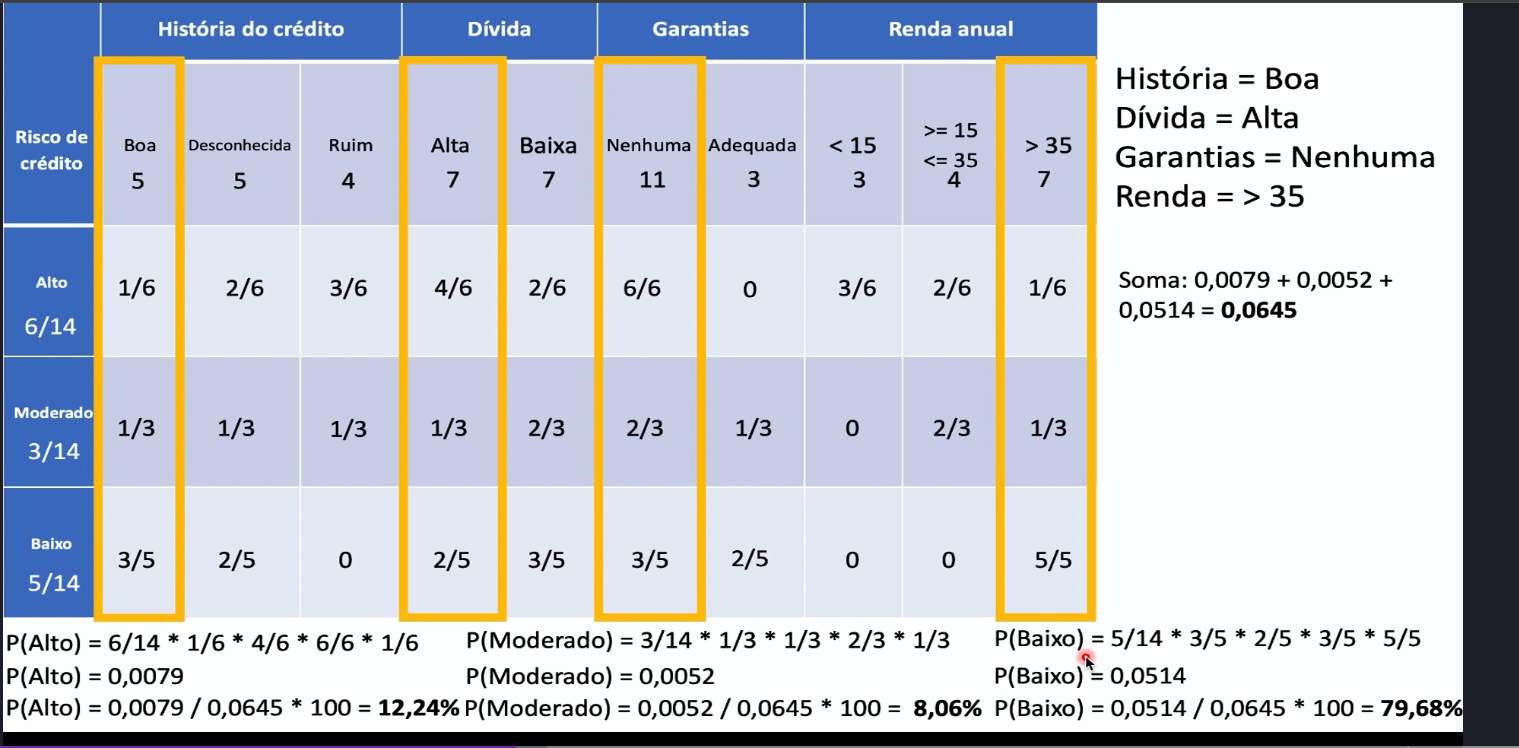

In [101]:
pprint(list(previsoes)[-25:])


[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [102]:
pprint(list(y_credit_teste)[-25:])


[0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1]


sklearn.metrics.accuracy_score(y_true, y_pred, *, normalize=True, sample_weight=None)

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html

In [103]:
# Vamos comparar as respostas reais e com os registros - usar o sklearn. 

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# accuracy_score -> de quantos acertos e quantos erros. 

accuracy_score(y_credit_teste, previsoes)*100
# percentual de acertos => houve 80,05% de acertos em toda a base de dados de teste

80.05155904738523

# Matriz de confusão 

sklearn.metrics.confusion_matrix(y_true, y_pred, *, labels=None, sample_weight=None, normalize=None)

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

In [104]:
confusion_matrix(y_credit_teste, previsoes)

array([[6350,  132],
       [1493,  171]])

# matriz acerto classe por classe

array([[6350,  132],  -> linha zero indica clientes que pagam os impréstimos 

       [1493,  171]]) -> linha 1 indica os clientes que não pagam os impréstimos. 

# matriz acerto classe por classe
array([["clientes que pagam corretamente",  "clientes que pagam que foram classificados como clientes que não pagam(1)"],  

       ["clientes que NÃO PAGAM",  "clientes que NÃO PAGAM que foram classificados como clientes que pagam(0)"]]) 

In [108]:
#!pip install yellowbrick


In [109]:
 # ficar fácil a visualização
from yellowbrick.classifier import ConfusionMatrix
cm = ConfusionMatrix(naive_credit_data)


0.8005155904738522

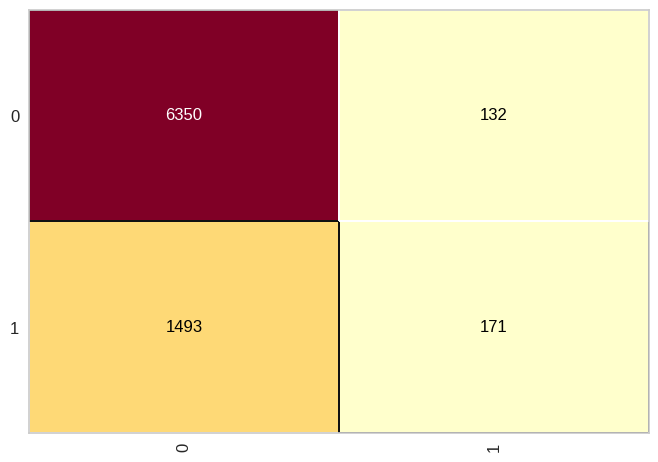

In [110]:
# fazer novamente o treinamento
cm.fit(X_credit_treinamento, y_credit_treinamento)
cm.score(X_credit_teste, y_credit_teste)

In [111]:
# correto a intersecção 0x0 e 1x1

In [114]:
# 1 não paga, 0 paga o empréstimo

In [116]:
# problema do 1x0, pois não paga e é considerado como paga (problema para o banco)
# verificar a avaliação o algoritmo

sklearn.metrics.classification_report(y_true, y_pred, *, labels=None, target_names=None, sample_weight=None, digits=2, output_dict=False, zero_division='warn')

https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html


In [117]:
print(classification_report(y_credit_teste, previsoes))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89      6482
           1       0.56      0.10      0.17      1664

    accuracy                           0.80      8146
   macro avg       0.69      0.54      0.53      8146
weighted avg       0.76      0.80      0.74      8146



In [119]:
#  accuracy a f1-score
# verificar o algoritmo

In [124]:
# suporte - o quanto paga (0)
# suporte - o quanto não paga (1)

# recall realmente indica bem 98% e a precision em 81%, muito bom -> 0 nas pessoas que pagam

# recall realmente indica pouco o cliente que não paga (1) 10% e a precision em 56% 
#-> porém não é tão bom para capturar o cliente que não paga 
# problema não indicar bem quem não paga, pode dar problema no banco


In [125]:
# o score é bom na previsão -> 0.8005155904738522, na matrix confusão, porém só é bom no item 0, das pessoas que pagam

# 4.0) Naive bayes - base censo


In [126]:
#import pickle
# read =rb 
with open('../2-3-Classificacao/census_aula.pkl', 'rb') as f:
  X_census_treinamento, y_census_treinamento, X_census_teste, y_census_teste = pickle.load(f)


In [127]:
X_census_treinamento.shape, y_census_treinamento.shape, 
# colunas grandes por conta --> onehotencoded


((27676, 108), (27676,))

In [129]:
#x=['age', 'workclass', 'final-weight', 'education', 'education-num',
#       'marital-status', 'occupation', 'relationship', 'race', 'sex',
#       'capital-gain', 'capital-loos', 'hour-per-week', 'native-country']
#y=['income'], renda se a pessoa gua mais de 50 mil dolares ou não por mês


In [128]:
X_census_teste.shape, y_census_teste.shape

((4885, 108), (4885,))

In [130]:
X_census_teste.shape, y_census_teste.shape

((4885, 108), (4885,))

In [131]:
# vamos fazer o treinamento primeiramente pelo Naive Bayes

naive_census = GaussianNB()

# criação da tabela de probabilidade
naive_census.fit(X_census_treinamento, y_census_treinamento)

GaussianNB()

In [132]:
# verificar a previsão ( com base dos dados iniciais de teste X=[]
previsoes = naive_census.predict(X_census_teste)
previsoes

array([' >50K', ' >50K', ' >50K', ..., ' <=50K', ' >50K', ' >50K'],
      dtype='<U6')

In [134]:
pprint(previsoes[:15])

array([' >50K', ' >50K', ' >50K', ' <=50K', ' >50K', ' >50K', ' <=50K',
       ' >50K', ' >50K', ' <=50K', ' <=50K', ' >50K', ' >50K', ' <=50K',
       ' >50K'], dtype='<U6')


In [135]:
y_census_teste

array([' <=50K', ' <=50K', ' <=50K', ..., ' <=50K', ' <=50K', ' <=50K'],
      dtype=object)

In [136]:
pprint(y_census_teste[:15])

array([' <=50K', ' <=50K', ' <=50K', ' <=50K', ' >50K', ' <=50K',
       ' <=50K', ' <=50K', ' >50K', ' <=50K', ' <=50K', ' <=50K', ' >50K',
       ' <=50K', ' <=50K'], dtype=object)


In [137]:
# notamos acima alguns erros da previsão
#analisar com mais destalhes abaixo

In [138]:
# vamos verificar a taxa de acerto
accuracy_score(y_census_teste, previsoes) # aula ->não executar o escalonamento (da padronização)

0.4767656090071648

In [149]:
# Percentual de acerto baixo 
print("Percentual de acerto: {:.2f} %".format(accuracy_score(y_census_teste, previsoes)*100).replace('.',',') )

Percentual de acerto: 47,68 %


In [150]:
# só existe dois casos para a análise '>50K' e ' <=50K'
# método não deu certo, interessante usar cara e coroa, número aleatório 50% 
# O método random em Python é usado para gerar números aleatórios -> método randômico python

Padronização (StandardScaler)

Subtrai a média e divide pelo desvio padrão → Resulta em média = 0 e desvio padrão = 1.

Exemplo com StandardScaler do scikit-learn:

In [151]:
#from sklearn.preprocessing import StandardScaler
#scaler = StandardScaler()
#dados_escalonados = scaler.fit_transform(dados_originais)
#Normalização (MinMaxScaler)


Transforma os valores para um intervalo (geralmente entre 0 e 1).

Exemplo com MinMaxScaler:

In [152]:
#from sklearn.preprocessing import MinMaxScaler
#scaler = MinMaxScaler()
#dados_normalizados = scaler.fit_transform(dados_originais)

Quando NÃO executar o escalonamento?

Se os dados já estiverem em uma escala semelhante.

Se o algoritmo não precisar de escalonamento (Ex.: Árvores de decisão, Random Forest).

Quando os valores possuem significados absolutos importantes (Ex.: Preços, Contagens).

## matriz da confusão

0.4767656090071648

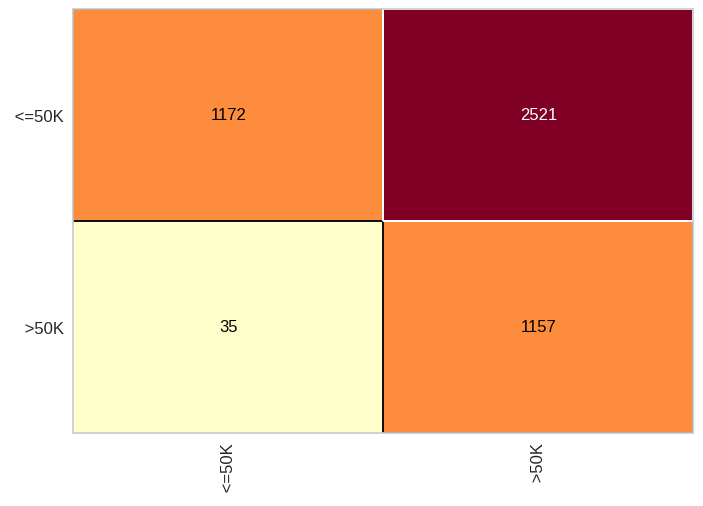

In [154]:
cm = ConfusionMatrix(naive_census)
cm.fit(X_census_treinamento, y_census_treinamento)
cm.score(X_census_teste, y_census_teste)



matrix y <=50K x <=50K -> 1172 foram classificados corretamente

matrix y <=50K x >50K -> 2521 foram classificados incorretamente (classificados como se ganhassem mais) -> errou muito

matrix y >50K x >50K -> 1157 foram classificados corretamente com >50k

matrix y >50K x <=50K -> 35 foram classificados erradamente, era para ser >50K ao invés de <=50K

In [155]:
print(classification_report(y_census_teste, previsoes))

              precision    recall  f1-score   support

       <=50K       0.97      0.32      0.48      3693
        >50K       0.31      0.97      0.48      1192

    accuracy                           0.48      4885
   macro avg       0.64      0.64      0.48      4885
weighted avg       0.81      0.48      0.48      4885



## análise com dados desbalanceados

support :

'<=50K'   3693 , dados maiores

'>50K'      quantidade de  1192, menor que o anterior

o algoritmo consegue identificar 97% dos dados de '>50K', porém quando identifica, só consegue ter uma precisão de apenas 31%

##### o algoritmo errou bastante o '<=50K', conseguiu identificar apenas 32% dos dados, e quando identifica, consegue ter uma precisão de 97%